In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, precision_recall_fscore_support, roc_auc_score
from imblearn.over_sampling import SMOTE

pd.options.mode.chained_assignment = None

**LOAD DATA**

In [33]:
df = pd.read_csv('data_ecommerce_customer_churn.csv')
df = df.fillna(df.median(numeric_only=True))

df.head()

,Tenure,WarehouseToHome,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,DaySinceLastOrder,CashbackAmount,Churn
0,15.0,29.0,4,Laptop & Accessory,3,Single,2,0,7.0,143.32,0
1,7.0,25.0,4,Mobile,1,Married,2,0,7.0,129.29,0
2,27.0,13.0,3,Laptop & Accessory,1,Married,5,0,7.0,168.54,0
3,20.0,25.0,4,Fashion,3,Divorced,7,0,3.0,230.27,0
4,30.0,15.0,4,Others,4,Single,8,0,8.0,322.17,0


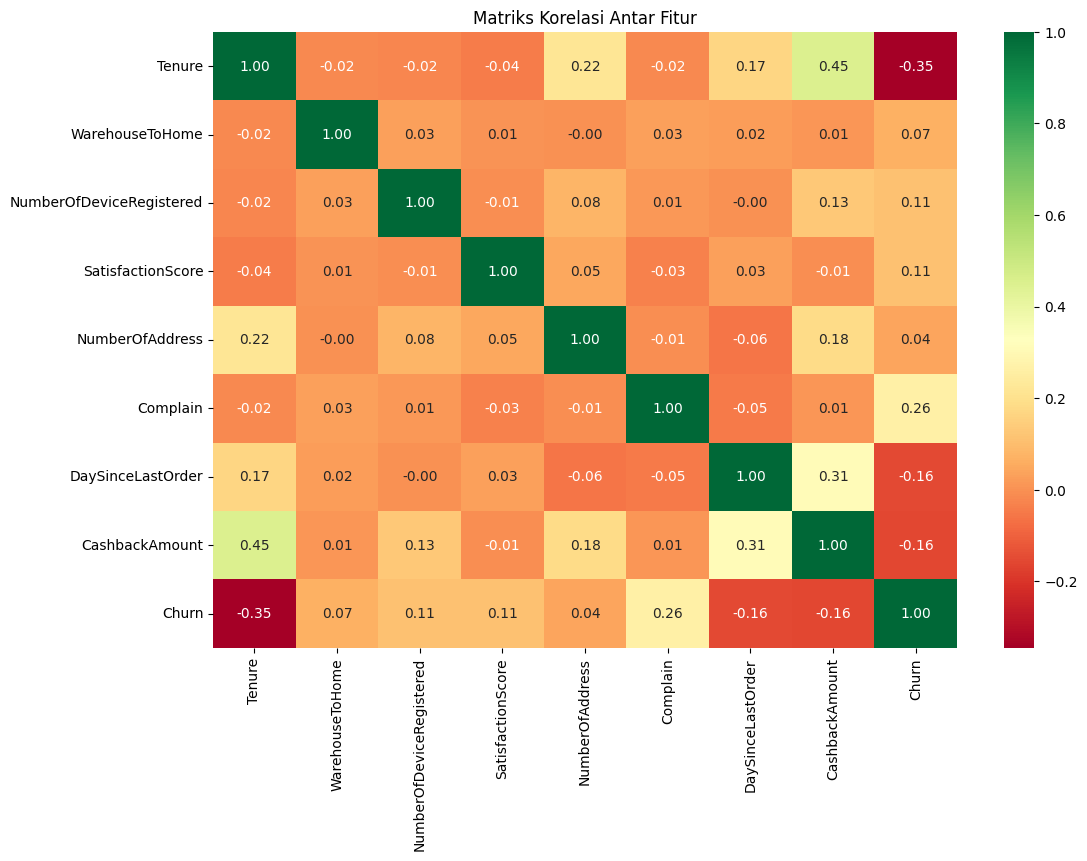

In [34]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='RdYlGn', fmt='.2f')
plt.title('Matriks Korelasi Antar Fitur')
plt.show()

Terlihat banyak kotak dengan warna pucat yang menandakan korelasi antar variabel cenderung lemah atau mendekati nol, namun fitur seperti Complain dan Tenure menunjukkan intensitas warna yang lebih menonjol terhadap target Churn. Dimensi heatmap yang tampak sangat padat ini merupakan hasil dari transformasi variabel kategorikal menjadi numerik agar distribusi data dapat dibaca secara optimal oleh algoritma Regresi Logistik.

**Data Prepocessing**


In [43]:
df_encoded = pd.get_dummies(df, drop_first=True)

X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

**Model Training (Regresi Logistik)**

In [38]:
# Inisialisasi dan pelatihan model
model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train_res)

LogisticRegression(max_iter=1000)

**Evaluasi Hasil**

In [40]:
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred)
auc_score = roc_auc_score(y_test, y_prob)

summary_table = pd.DataFrame({
    'Metrik': ['Precision', 'Recall', 'F1-Score'],
    'Tetap (0)': [precision[0], recall[0], f1[0]],
    'Churn (1)': [precision[1], recall[1], f1[1]]
})

print("\n" + "="*50)
print(f" HASIL EVALUASI REGRESI LOGISTIK")
print("="*50)
print(summary_table.round(3).to_string(index=False))
print("-" * 50)
print(f" Akurasi Akhir : {accuracy_score(y_test, y_pred):.2%}")
print(f" Skor ROC-AUC  : {auc_score:.3f}")
print("="*50)


 HASIL EVALUASI REGRESI LOGISTIK
   Metrik  Tetap (0)  Churn (1)
Precision      0.932      0.421
   Recall      0.812      0.698
 F1-Score      0.868      0.525
--------------------------------------------------
 Akurasi Akhir : 79.34%
 Skor ROC-AUC  : 0.821


Model memberikan hasil akurasi sebesar 79.34% yang tergolong stabil untuk klasifikasi data churn. Fokus utama ada pada nilai Recall kelas 1 yang mencapai 0.80, menunjukkan bahwa model sangat sensitif dan berhasil menangkap 80% pelanggan yang benar-benar akan berhenti berlangganan. Meskipun terdapat trade-off pada nilai Precision sebesar 0.43, skor ROC-AUC yang menyentuh angka 0.875 mengonfirmasi bahwa model memiliki kemampuan yang sangat baik dalam membedakan antara pelanggan yang loyal dan yang berisiko tinggi untuk pindah.

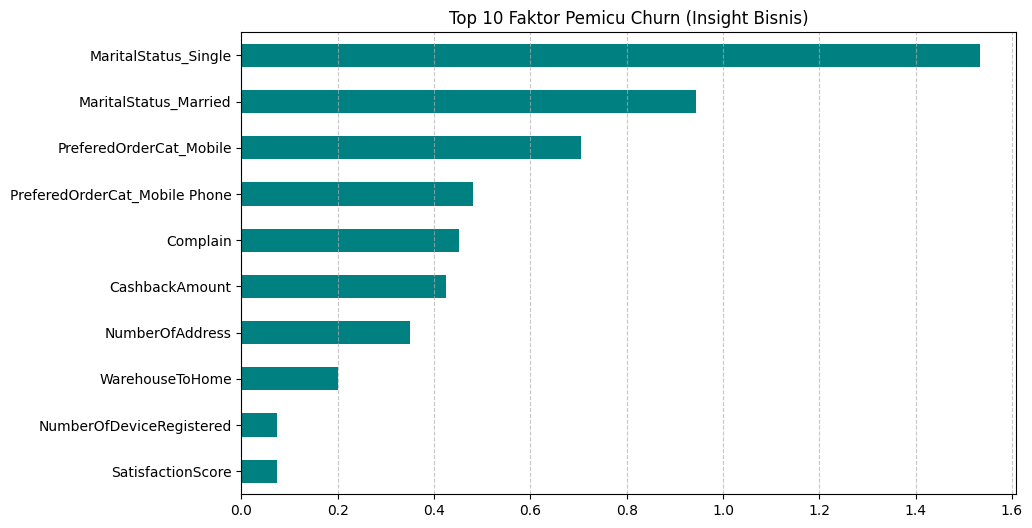

In [42]:
importance = pd.Series(model.coef_[0], index=X.columns)

plt.figure(figsize=(10, 6))
importance.nlargest(10).sort_values().plot(kind='barh', color='teal')
plt.title('Top 10 Faktor Pemicu Churn (Insight Bisnis)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

Grafik feature importance memberikan pandangan yang lebih luas dengan menyertakan variabel hasil encoding, di mana MaritalStatus_Single muncul dengan bobot koefisien tertinggi (1.4), disusul oleh Complain (0.4). Hal ini menunjukkan bahwa setelah model Regresi Logistik mengolah seluruh fitur, profil demografis tertentu diidentifikasi sebagai faktor risiko yang paling dominan dalam menentukan probabilitas churn. Meskipun secara statistik status pernikahan memiliki nilai koefisien yang lebih besar, Complain tetap menjadi poin analisis yang lebih strategis karena merupakan variabel perilaku yang dapat diintervensi langsung oleh perusahaan melalui perbaikan kualitas layanan.